In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random


In [2]:
## -- 시드 고정 --

def set_seed(seed):
    random.seed(seed) # 파이썬 기본 랜덤 고정
    np.random.seed(seed) # 넘파이 랜덤 고정
    torch.manual_seed(seed) # 파이토치 CPU 랜덤 고정
    torch.cuda.manual_seed(seed) # 파이토치 GPU 랜덤 고정
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 고정

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:

# --- [하이퍼파라미터 설정] ---

HIDDEN_NODES1 = 100
HIDDEN_NODES2 = 50
HIDDEN_NODES3 = 30
HIDDEN_NODES4 = 20
LR = 0.01
BATCH_SIZE = 100
EPOCHS = 20
ACTIVATION = 'ReLU' #

# 실험
OPTIMIZER = "SGD" # OR ADAM
INIT = "XAVIER" # OR HE
DROPOUT=False # OR True



In [4]:

# --- [데이터 준비] ---
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [5]:

# Train(5만) / Validation(1만) 분리
train_dataset, val_dataset = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [6]:

# --- [모델 설계] ---
class MNIST_Net(nn.Module):
    def __init__(self, hidden_size1,hidden_size2,hidden_size3,hidden_size4, act_type):
        super(MNIST_Net, self).__init__()
        self.fc1 = nn.Linear(784, hidden_size1) # 입력층 784 -> 레이어2
        self.fc2 = nn.Linear(hidden_size1,hidden_size2)
        self.fc3 = nn.Linear(hidden_size2,hidden_size3)
        self.fc4 = nn.Linear(hidden_size3,hidden_size4)
        self.fc5 = nn.Linear(hidden_size4, 10)  #  -> 출력층 10
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2 if DROPOUT else 0.0) #or 0.5

        for m in self.modules():
            if isinstance(m, nn.Linear):
                if INIT == "XAVIER":
                    nn.init.xavier_normal_(m.weight)
                elif INIT == "HE":
                    nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)


    def forward(self, x):
        x= x.view(-1,784)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.activation(self.fc3(x))
        x = self.dropout(x)
        x = self.activation(self.fc4(x))
        x = self.dropout(x)

        return self.fc5(x)

model = MNIST_Net(HIDDEN_NODES1,HIDDEN_NODES2,HIDDEN_NODES3,HIDDEN_NODES4, ACTIVATION)
criterion = nn.CrossEntropyLoss() # 손실함수 crossentropyloss


if OPTIMIZER == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LR)
elif OPTIMIZER == "ADAM":
    optimizer = optim.Adam(model.parameters(), lr=LR)


In [7]:

# 기록용 리스트
train_losses = []
val_accuracies = []
train_accuracies = []


# --- [학습 루프] ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    train_acc =0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _,predicted=torch.max(outputs.data,1)
        train_acc += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    avg_train_acc=100*train_acc/len(train_dataset)
    train_accuracies.append(avg_train_acc)
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / len(val_dataset)
    val_accuracies.append(val_acc)


    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")



Epoch [1/20] Loss: 2.0730, Train Acc: 24.39%, Val Acc: 63.94%
Epoch [2/20] Loss: 1.4995, Train Acc: 51.22%, Val Acc: 77.65%
Epoch [3/20] Loss: 1.1020, Train Acc: 64.81%, Val Acc: 83.13%
Epoch [4/20] Loss: 0.8995, Train Acc: 71.12%, Val Acc: 86.99%
Epoch [5/20] Loss: 0.7832, Train Acc: 75.24%, Val Acc: 88.26%
Epoch [6/20] Loss: 0.7108, Train Acc: 77.96%, Val Acc: 89.39%
Epoch [7/20] Loss: 0.6422, Train Acc: 80.50%, Val Acc: 90.21%
Epoch [8/20] Loss: 0.5960, Train Acc: 82.20%, Val Acc: 91.17%
Epoch [9/20] Loss: 0.5592, Train Acc: 83.51%, Val Acc: 91.84%
Epoch [10/20] Loss: 0.5272, Train Acc: 84.67%, Val Acc: 92.30%
Epoch [11/20] Loss: 0.4946, Train Acc: 85.85%, Val Acc: 92.80%
Epoch [12/20] Loss: 0.4643, Train Acc: 86.70%, Val Acc: 93.15%
Epoch [13/20] Loss: 0.4408, Train Acc: 87.62%, Val Acc: 93.27%
Epoch [14/20] Loss: 0.4172, Train Acc: 88.43%, Val Acc: 93.65%
Epoch [15/20] Loss: 0.3969, Train Acc: 88.96%, Val Acc: 93.92%
Epoch [16/20] Loss: 0.3819, Train Acc: 89.49%, Val Acc: 94.11%
E

In [8]:
# --- [최종 Test Accuracy] ---
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
print(f"\n최종 Test Accuracy: {100 * correct / len(test_dataset):.2f}%")


최종 Test Accuracy: 95.28%


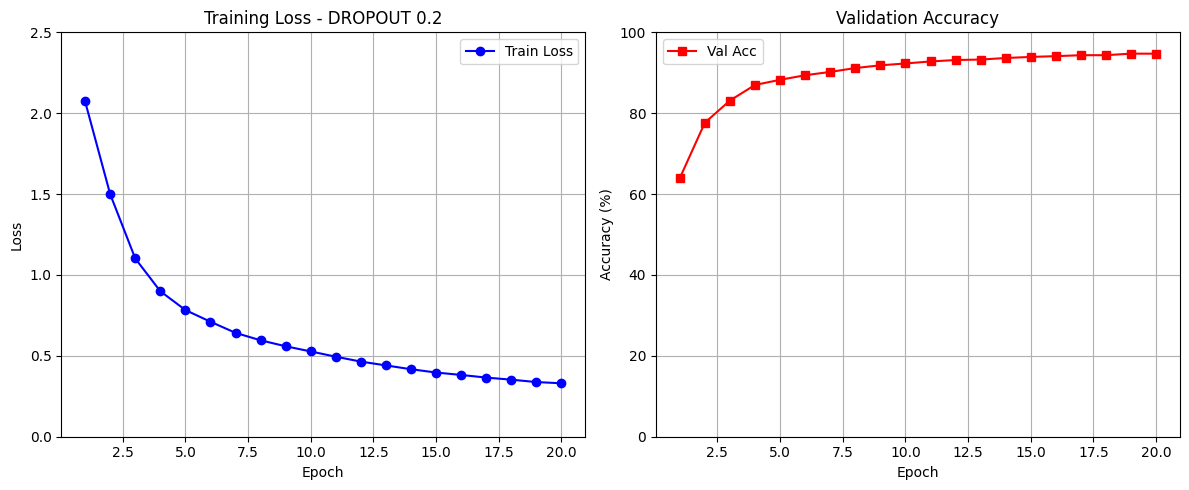

In [9]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- 왼쪽: Training Loss (스케일 0 ~ 2.5 고정!) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss - DROPOUT 0.2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy (스케일 0 ~ 100 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()